# **ICU DB Merged - Optimized EDA/PREPROCESS** 
------------------------------------
**Goal:** make a model that is optimized, regardless of realistic situations and see how that performs and what that means


**Dataset Overview:**
- Loaded mergeICU_db.csv (2,520 ICU stays, 55 raw features)
- Contains demographics, comorbidities, hospital info, APACHE scores, APS physiology, and 0–24h vitals/labs


**1. Data Cleaning**
- Dropped irrelevant ID (patientunitstayid)
- Converted age from string → numeric; added age_gt89 flag; mapped ">89" → 95 (APACHE convention)
- Fixed physiologic impossibilities (e.g., MAP <10, SpO₂ <50, HR <20, RR <4, enormous urine outputs → NaN)


**2. Categorical Processing**
- Converted major columns to categorical
- Collapsed rare categories (<2%) into "Other" to reduce sparsity


**3. Missing Data Imputation**
- Used IterativeImputer (MICE-style) for all numeric columns → 0 missing values remain
- Restored categorical dtypes afterward


**4. Feature Engineering for Optimized Modeling**
- Created three versions of all continuous numeric features:
  - Raw
  - Windsorized (_w) — clipped at 0.5–99.5th percentiles
  - Log-transformed (_log) — log1p applied to windsorized values
- Expanded feature set to ~127 columns for maximal predictive performance


**5. Diagnostic Checks**
- Raw and transformed distributions look correct (skew improved, outliers constrained)
- Categorical columns balanced after collapsing rare levels
- Correlation matrix shows expected clinical patterns
- Identified near-zero variance feature: aids (will drop in modeling)
---------------------------

## **EDA Again** 

In [38]:
# load in imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  
import math


# preprocessing
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [7]:
# load in data
icu_df = pd.read_csv("mergeICU_db.csv")

# overview 
print("Shape:", icu_df.shape)
print("\nData Types:\n", icu_df.dtypes)

Shape: (2520, 55)

Data Types:
 patientunitstayid         int64
gender                   object
age                      object
ethnicity                object
hospitalid                int64
unittype                 object
admissionheight         float64
admissionweight         float64
dischargeweight         float64
unitadmitsource          object
hospitaladmitsource      object
numbedscategory          object
teachingstatus           object
region                   object
acutephysiologyscore    float64
apachescore             float64
intubated               float64
dialysis                float64
temperature             float64
respiratoryrate         float64
heartrate               float64
meanbp                  float64
urine                   float64
creatinine              float64
bun                     float64
sodium                  float64
hematocrit              float64
albumin                 float64
glucose                 float64
bilirubin               float64
pao2    

In [9]:
# looking at basic stats
icu_df.describe(include='all')

,patientunitstayid,gender,age,ethnicity,hospitalid,unittype,admissionheight,admissionweight,dischargeweight,unitadmitsource,...,ventday1,nettotal,sao2_mean,sao2_min,heartrate_mean,heartrate_max,heartrate_std,respiration_mean,respiration_max,bad_outcome
count,2.520000e+03,2516,2516,2481,2520.000000,2520,2451.000000,2322.000000,1236.000000,2498,...,2205.000000,2185.000000,2321.000000,2321.000000,2360.000000,2360.000000,2357.000000,2153.000000,2153.000000,2520.000000
unique,NaN,2,76,6,NaN,8,NaN,NaN,NaN,13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Male,> 89,Caucasian,NaN,Med-Surg ICU,NaN,NaN,NaN,Emergency Department,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1508,98,2010,NaN,1898,NaN,NaN,NaN,1304,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1.666226e+06,NaN,NaN,NaN,261.042460,NaN,169.740445,83.087795,83.051586,NaN,...,0.202721,-137.265126,96.302555,85.684619,84.271084,107.366525,7.911866,19.516703,32.542963,0.116270
std,1.022224e+06,NaN,NaN,NaN,119.109829,NaN,15.986092,26.606384,26.465304,NaN,...,0.402118,17441.153120,3.482072,13.987204,17.013917,22.580007,4.886430,5.118551,14.123662,0.320612
min,1.417640e+05,NaN,NaN,NaN,56.000000,NaN,0.300000,0.500000,22.300000,NaN,...,0.000000,-174237.000000,41.015748,0.000000,28.272727,47.000000,0.000000,0.000000,0.000000,0.000000
25%,7.722628e+05,NaN,NaN,NaN,158.000000,NaN,162.600000,65.500000,64.275000,NaN,...,0.000000,-4081.050000,95.161871,83.000000,71.962058,92.000000,4.933572,16.302041,24.000000,0.000000
50%,1.590372e+06,NaN,NaN,NaN,252.500000,NaN,170.200000,79.300000,79.550000,NaN,...,0.000000,-550.000000,96.743169,90.000000,82.815565,105.000000,6.873239,18.783972,29.000000,0.000000
75%,2.697422e+06,NaN,NaN,NaN,384.500000,NaN,177.800000,96.600000,98.400000,NaN,...,0.000000,2456.000000,98.170854,93.000000,95.875264,122.000000,9.651834,22.006944,36.000000,0.000000


In [11]:
# looking at missing values
icu_df.isna().sum().sort_values(ascending=False)

electivesurgery         2178
dischargeweight         1284
apachescore              682
acutephysiologyscore     682
hospitaladmitsource      594
respiration_max          367
respiration_mean         367
numbedscategory          346
nettotal                 335
albumin                  315
admitsource              315
aids                     315
fio2                     315
ph                       315
lymphoma                 315
pco2                     315
pao2                     315
hepaticfailure           315
immunosuppression        315
metastaticcancer         315
leukemia                 315
glucose                  315
cirrhosis                315
diabetes                 315
activetx                 315
ventday1                 315
bilirubin                315
sodium                   315
intubated                315
bun                      315
creatinine               315
urine                    315
meanbp                   315
heartrate                315
respiratoryrat

In [13]:
# numerical and categorical columns
num_cols = icu_df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = icu_df.select_dtypes(include=['object', 'category']).columns

print("Numerical columns:", num_cols)
print("\nCategorical columns:", cat_cols)

Numerical columns: Index(['patientunitstayid', 'hospitalid', 'admissionheight', 'admissionweight',
       'dischargeweight', 'acutephysiologyscore', 'apachescore', 'intubated',
       'dialysis', 'temperature', 'respiratoryrate', 'heartrate', 'meanbp',
       'urine', 'creatinine', 'bun', 'sodium', 'hematocrit', 'albumin',
       'glucose', 'bilirubin', 'pao2', 'pco2', 'fio2', 'ph', 'admitsource',
       'aids', 'hepaticfailure', 'lymphoma', 'metastaticcancer', 'leukemia',
       'immunosuppression', 'cirrhosis', 'diabetes', 'electivesurgery',
       'activetx', 'ventday1', 'nettotal', 'sao2_mean', 'sao2_min',
       'heartrate_mean', 'heartrate_max', 'heartrate_std', 'respiration_mean',
       'respiration_max', 'bad_outcome'],
      dtype='object')

Categorical columns: Index(['gender', 'age', 'ethnicity', 'unittype', 'unitadmitsource',
       'hospitaladmitsource', 'numbedscategory', 'teachingstatus', 'region'],
      dtype='object')


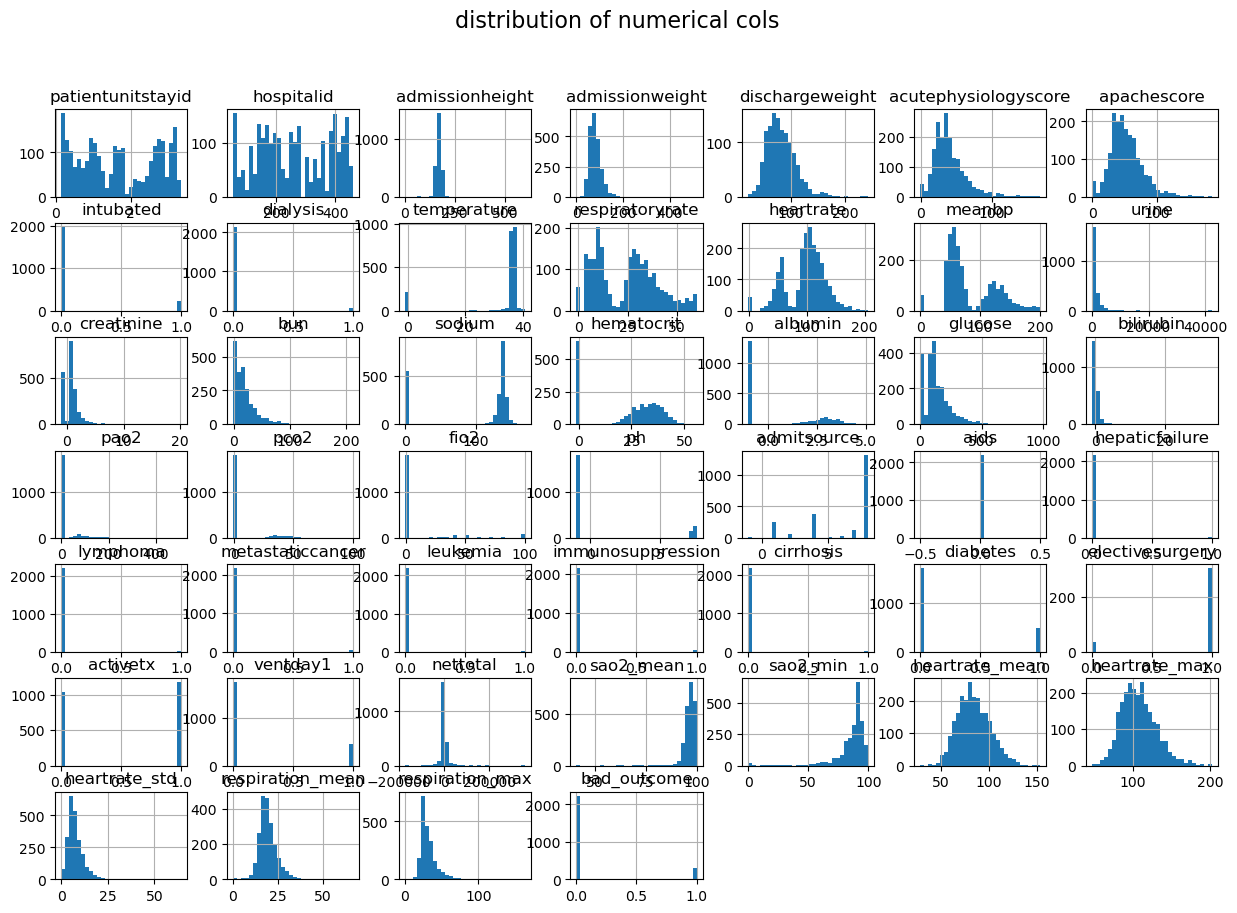

In [15]:
# looking into numerical cols 
# stats
icu_df[num_cols].describe().T

# histograms 
icu_df[num_cols].hist(bins=30, figsize=(15, 10))
plt.suptitle('distribution of numerical cols', fontsize=16)
plt.show()

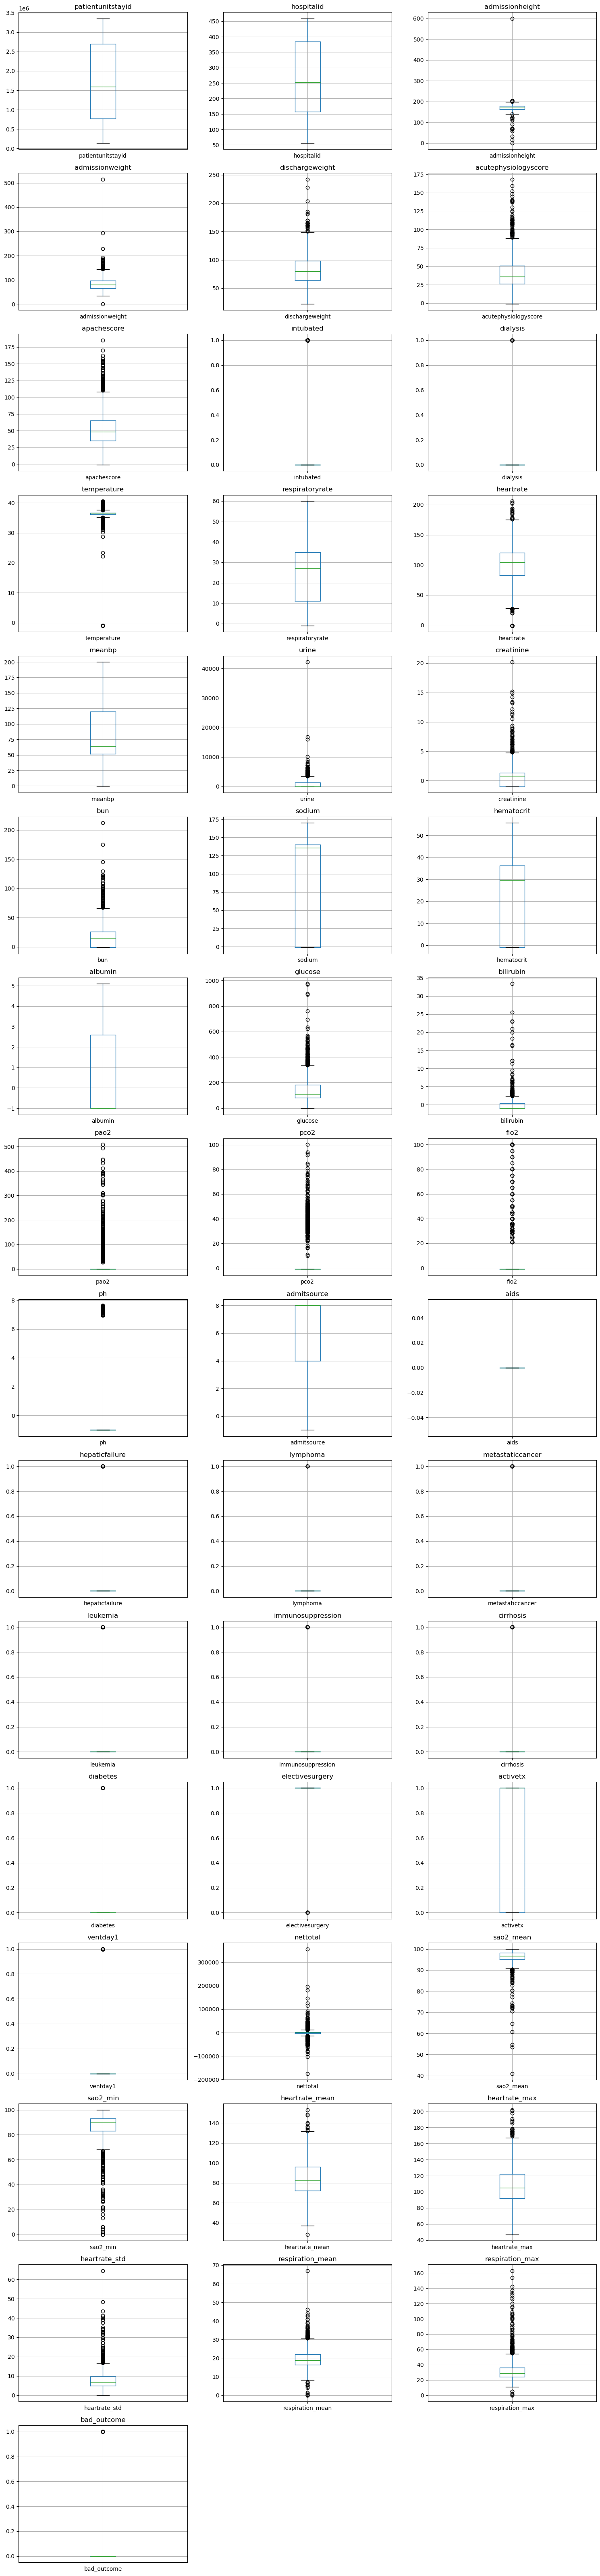

In [17]:
# numerical cols outlier boxplots
n_cols = 3  # number of plots per row
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(15, n_rows * 4))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    icu_df.boxplot(column=col)
    plt.title(col)

plt.tight_layout()
plt.show()

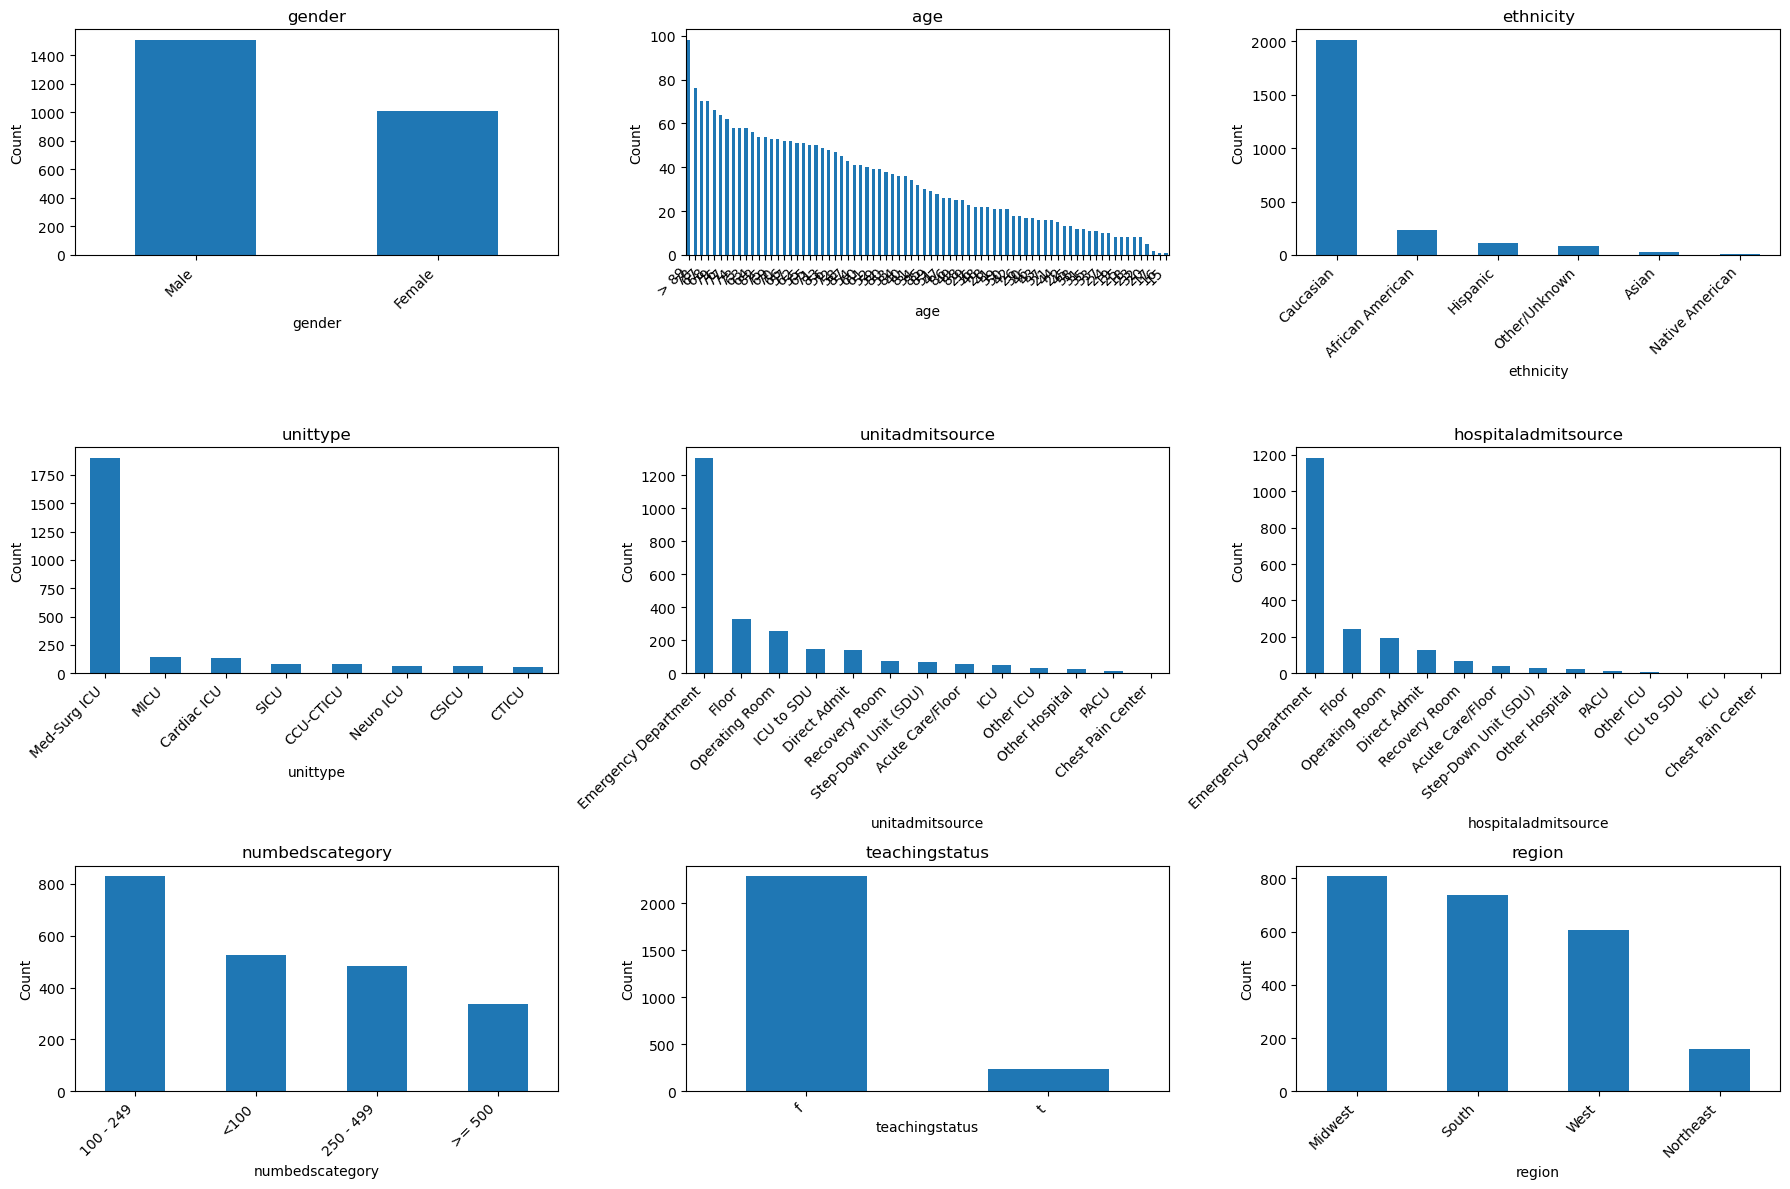

In [19]:
# now to look into categorical cols
n_cols = 3  # number of plots per row
n_rows = math.ceil(len(cat_cols) / n_cols)

plt.figure(figsize=(18, n_rows * 4))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    icu_df[col].value_counts().plot(kind='bar')
    plt.title(f'{col}')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

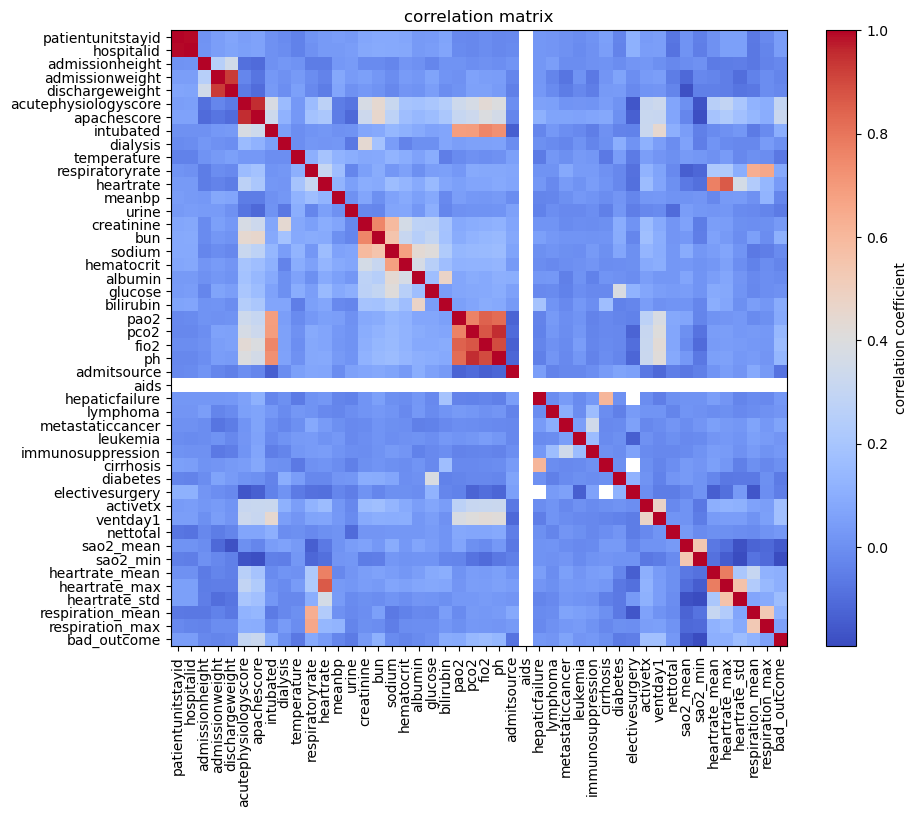

hospitalid            patientunitstayid       0.993541
patientunitstayid     hospitalid              0.993541
acutephysiologyscore  apachescore             0.949360
apachescore           acutephysiologyscore    0.949360
pco2                  ph                      0.949168
ph                    pco2                    0.949168
dischargeweight       admissionweight         0.926628
admissionweight       dischargeweight         0.926628
fio2                  ph                      0.894976
ph                    fio2                    0.894976
dtype: float64


In [21]:
# correlation for numerical cols 
icu_corr = icu_df[num_cols].corr()

plt.figure(figsize=(10, 8))
plt.imshow(icu_corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='correlation coefficient')
plt.xticks(range(len(icu_corr)), icu_corr.columns, rotation=90)
plt.yticks(range(len(icu_corr)), icu_corr.columns)
plt.title('correlation matrix')
plt.show()

# top correlated pairs
corr_pairs = icu_corr.unstack().sort_values(ascending=False)
print(corr_pairs[corr_pairs < 1].head(10))

-----------------------------------------------------------
## **Preprocessing**

In [24]:
# setup & basic column roles 
target_col = "bad_outcome"

# columns that are pure identifiers (not necessarily useful for prediction)
id_cols = ["patientunitstayid"]   # keep hospitalid as a hospital feature FOR NOW

# work on a copy
prep_df = icu_df.copy()

# now drop ids from feature frame
prep_df = prep_df.drop(columns=id_cols)
print("Shape after ID drop:", prep_df.shape)

Shape after ID drop: (2520, 54)


In [26]:
# fixing the age (from object to numeric + >89 bucket)

# clean age col
age_str = prep_df["age"].astype(str)

# indicator for "> 89" bucket
prep_df["age_gt89"] = age_str.str.contains(">").astype(int)

# extract digits, coerce to float
age_numeric = (
    age_str
      .str.extract(r"(\d+)", expand=False)
      .astype(float)
)

prep_df["age_years"] = age_numeric

# set all "> 89" cases to 95 (APACHE convention for very old)
prep_df.loc[prep_df["age_gt89"] == 1, "age_years"] = 95.0

# drop original age string column
prep_df = prep_df.drop(columns=["age"])
prep_df[["age_gt89", "age_years"]].head()

,age_gt89,age_years
0,0,87.0
1,0,87.0
2,0,76.0
3,0,34.0
4,0,61.0


In [28]:
# marking categorical cols and collapse other rare levels

# define cat cols 
cat_cols = [
    "gender",
    "ethnicity",
    "unittype",
    "unitadmitsource",
    "hospitaladmitsource",
    "numbedscategory",
    "teachingstatus",
    "region"
]

for c in cat_cols:
    prep_df[c] = prep_df[c].astype("category")

# collapse rare categories into "Other" (LESS THAN 2% OF ROWS)
rare_threshold = 0.02 * len(prep_df)

for c in cat_cols:
    vc = prep_df[c].value_counts()
    rare_levels = vc[vc < rare_threshold].index

    if len(rare_levels) > 0:
        prep_df[c] = prep_df[c].cat.add_categories("Other")
        prep_df.loc[prep_df[c].isin(rare_levels), c] = "Other"
        prep_df[c] = prep_df[c].cat.remove_unused_categories()

prep_df[cat_cols].describe()

,gender,ethnicity,unittype,unitadmitsource,hospitaladmitsource,numbedscategory,teachingstatus,region
count,2516,2481,2520,2498,1926,2174,2520,2310
unique,2,5,8,10,6,4,2,4
top,Male,Caucasian,Med-Surg ICU,Emergency Department,Emergency Department,100 - 249,f,Midwest
freq,1508,2010,1898,1304,1182,829,2285,807


In [30]:
# physiological sanity checks

# columns that should NEVER be negative
non_negative_cols = [
    "temperature", "respiratoryrate", "heartrate", "meanbp",
    "urine", "creatinine", "bun", "sodium", "hematocrit",
    "albumin", "glucose", "bilirubin", "pao2", "pco2", "fio2",
    "sao2_mean", "sao2_min", "respiration_mean", "respiration_max",
    "heartrate_mean", "heartrate_max", "heartrate_std"
]

for c in non_negative_cols:
    if c in prep_df.columns:
        prep_df.loc[prep_df[c] < 0, c] = np.nan

# more specific ICU rules (rough but safe)
# MAP too low/high
prep_df.loc[(prep_df["meanbp"] < 10) | (prep_df["meanbp"] > 300), "meanbp"] = np.nan

# SpO2 outside [50, 100]
for c in ["sao2_mean", "sao2_min"]:
    if c in prep_df.columns:
        prep_df.loc[(prep_df[c] < 50) | (prep_df[c] > 100), c] = np.nan

# implausible HR / RR
prep_df.loc[(prep_df["heartrate"] < 20) | (prep_df["heartrate"] > 250), "heartrate"] = np.nan
prep_df.loc[(prep_df["respiratoryrate"] < 4) | (prep_df["respiratoryrate"] > 70), "respiratoryrate"] = np.nan

# crazy urine outputs (very crude cap)
prep_df.loc[prep_df["urine"] > 40000, "urine"] = np.nan


# check em
prep_df[non_negative_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
temperature,1992.0,36.433524,0.906478,22.200000,36.200000,36.500000,36.770000,40.600000
respiratoryrate,2148.0,25.166667,14.767541,4.000000,11.000000,27.000000,35.000000,60.000000
heartrate,2163.0,100.253352,31.640464,20.000000,86.000000,104.000000,121.000000,206.000000
meanbp,2145.0,84.868531,40.130390,40.000000,53.000000,65.000000,120.000000,200.000000
urine,1064.0,1778.394830,1518.778438,0.000000,784.663200,1426.377600,2381.097600,16752.441600
creatinine,1644.0,1.510234,1.617267,0.100000,0.740000,1.000000,1.600000,20.200000
bun,1640.0,25.971409,20.059804,2.000000,13.000000,20.000000,32.000000,212.000000
sodium,1650.0,137.892970,5.865218,103.000000,135.000000,138.000000,141.000000,170.000000
hematocrit,1567.0,33.196682,6.798015,13.400000,28.100000,33.500000,38.100000,55.700000
albumin,854.0,2.872248,0.690135,1.200000,2.400000,2.900000,3.400000,5.100000


In [32]:
# re-identifying numeric vs cat for LATER steps

# num features, all number types except the target
num_cols = prep_df.select_dtypes(include=["int64", "float64"]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

# cat features (already chosen)
cat_cols = [c for c in cat_cols if c in prep_df.columns]

print("Numeric cols (excluding target):", len(num_cols))
print("\n\nCategorical cols:", len(cat_cols))

Numeric cols (excluding target): 46


Categorical cols: 8


### Imputation time!

In [40]:
# to keep track of og categoricals
cat_cols = [c for c in cat_cols if c in prep_df.columns]

# numeric coded copy for imputation
imp_df = prep_df.copy()

# convert categoricals into temporary integer codes for imputer
for c in cat_cols:
    imp_df[c] = imp_df[c].cat.codes.replace(-1, np.nan)  
    # -1 happens when category is missing; convert to NaN

# pull numeric cols for imputation
num_cols = [c for c in imp_df.select_dtypes(include=["int64", "float64"]).columns 
            if c != target_col]

# thee imputer
imp = IterativeImputer(random_state=42, max_iter=20, sample_posterior=False)

# fit the transform numeric data
imp_values = imp.fit_transform(imp_df[num_cols])

# put imputed values back into dataframe
imp_df[num_cols] = imp_values

# check it!
print("Remaining NaNs after impute:", imp_df[num_cols].isna().sum().sum())

Remaining NaNs after impute: 0


In [42]:
# restore categorical dtype (no more numeric codes)
for c in cat_cols:
    imp_df[c] = prep_df[c]   # original clean categories

# keeping imp_df as base going forward
prep_df = imp_df.copy()

### standardizing

In [47]:
# create windsorized and log features 

# re-identify numeric cols (after imputation) excluding target
num_cols = [c for c in prep_df.select_dtypes(include=["int64", "float64"]).columns
            if c != target_col]

# treating "continuous" features only (thiswill skip obvious binary flags)
# anything with >10 unique values "continuous-ish"
cont_cols = [c for c in num_cols if prep_df[c].nunique() > 10]

print("Continuous numeric cols to transform:", len(cont_cols))

# windsorization: clip to 0.5–99.5 percentiles
for c in cont_cols:
    lo = prep_df[c].quantile(0.005)
    hi = prep_df[c].quantile(0.995)
    prep_df[f"{c}_w"] = prep_df[c].clip(lower=lo, upper=hi)

# log transform of the WINDSORIZED version
# only log transform columns that are nonnegative
for c in cont_cols:
    w_col = f"{c}_w"
    if (prep_df[w_col] >= 0).all():
        # add a tiny epsilon so zeros are safe
        prep_df[f"{c}_log"] = np.log1p(prep_df[w_col])
    else:
        # if any negatives sneak through, skip log for that feature
        print(f"skip log transform for {c} (has negatives after clipping).")

# quick check
generated_cols = [c for c in prep_df.columns if c.endswith("_w") or c.endswith("_log")]
print("\n\nnew windsor/log feature count:", len(generated_cols))
prep_df[generated_cols].head()

Continuous numeric cols to transform: 44
skip log transform for acutephysiologyscore (has negatives after clipping).
skip log transform for apachescore (has negatives after clipping).
skip log transform for dialysis (has negatives after clipping).
skip log transform for urine (has negatives after clipping).
skip log transform for bilirubin (has negatives after clipping).
skip log transform for pao2 (has negatives after clipping).
skip log transform for ph (has negatives after clipping).
skip log transform for admitsource (has negatives after clipping).
skip log transform for hepaticfailure (has negatives after clipping).
skip log transform for lymphoma (has negatives after clipping).
skip log transform for metastaticcancer (has negatives after clipping).
skip log transform for leukemia (has negatives after clipping).
skip log transform for immunosuppression (has negatives after clipping).
skip log transform for cirrhosis (has negatives after clipping).
skip log transform for electivesu

,hospitalid_w,admissionheight_w,admissionweight_w,dischargeweight_w,acutephysiologyscore_w,apachescore_w,intubated_w,dialysis_w,temperature_w,respiratoryrate_w,...,activetx_log,ventday1_log,sao2_mean_log,sao2_min_log,heartrate_mean_log,heartrate_max_log,heartrate_std_log,respiration_mean_log,respiration_max_log,age_years_log
0,59.0,157.5,75.349903,75.354803,34.371109,54.922956,0.040846,-0.021448,36.651058,32.807402,...,0.46233,0.18071,4.563875,4.452547,4.678905,4.934474,2.512801,3.173839,3.630852,4.477337
1,59.0,157.5,46.500000,45.000000,23.000000,47.000000,0.000000,0.000000,36.200000,39.000000,...,0.00000,0.00000,4.580967,4.564348,4.433088,4.762174,2.200756,3.249700,3.688879,4.477337
2,68.0,167.0,77.500000,79.400000,43.000000,60.000000,0.000000,0.000000,36.400000,60.000000,...,0.00000,0.00000,4.577643,4.394449,3.890820,4.120581,1.279494,3.630872,4.465908,4.343805
3,56.0,172.7,60.300000,60.700000,25.000000,25.000000,0.000000,0.000000,36.700000,6.000000,...,0.00000,0.00000,4.601470,4.574711,4.440296,4.779123,2.440916,2.886323,3.761200,3.555348
4,68.0,177.8,91.700000,93.100000,26.000000,37.000000,0.000000,0.000000,36.200000,41.000000,...,0.00000,0.00000,4.572253,4.499810,4.196570,4.454347,2.181829,2.853547,3.737670,4.127134


In [49]:
# quick check

print("Remaining NaNs:", prep_df.isna().sum().sum())

# Features with near-zero variance (not helpful for modeling)
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold=0.0001)
vt.fit(prep_df.select_dtypes(include=["float64", "int64"]))

low_var_cols = [
    col for col, var in zip(
        prep_df.select_dtypes(include=["float64", "int64"]).columns,
        vt.variances_
    )
    if var < 0.0001
]

print("Low-variance cols:", low_var_cols)

Remaining NaNs: 1215
Low-variance cols: ['aids']


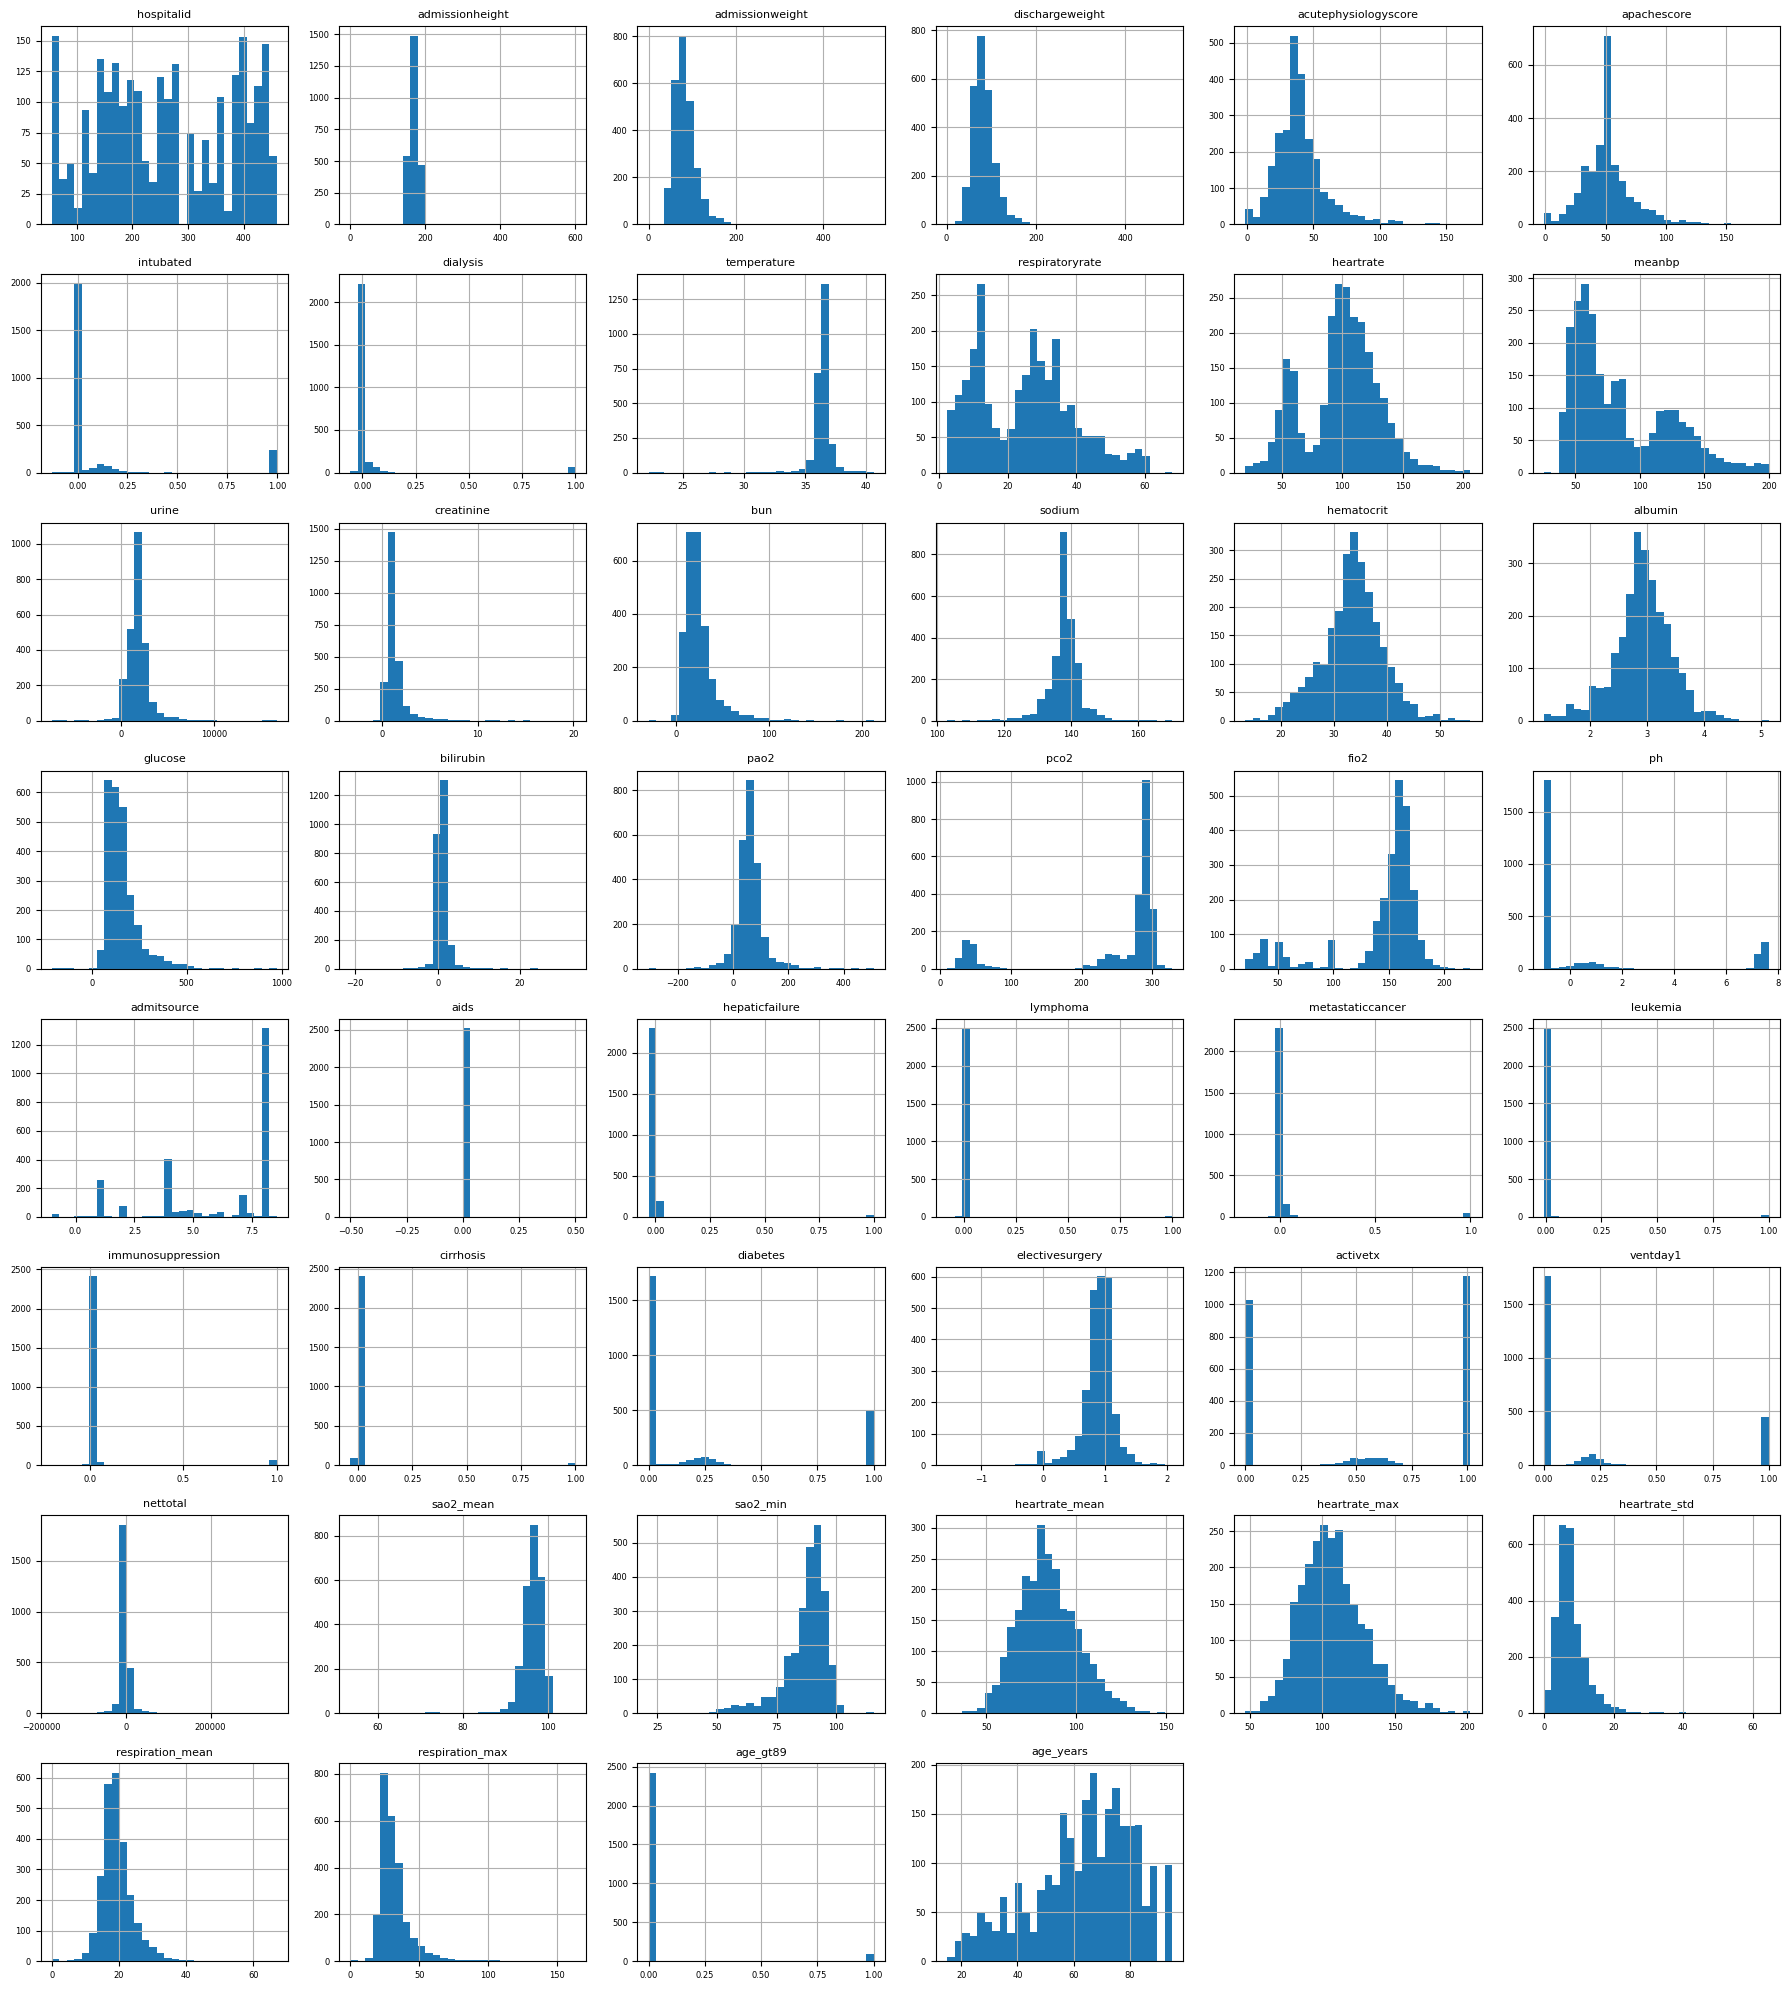

In [51]:
# last check before modeling

num_cols_raw = [c for c in prep_df.select_dtypes(include=["int64","float64"]).columns
                if not c.endswith("_w") and not c.endswith("_log")
                and c != target_col]

n = len(num_cols_raw)
ncols = 6
nrows = int(np.ceil(n / ncols))

plt.figure(figsize=(18, nrows * 2.5))

for i, col in enumerate(num_cols_raw, 1):
    plt.subplot(nrows, ncols, i)
    prep_df[col].hist(bins=30)
    plt.title(col, fontsize=8)
    plt.xticks(fontsize=6)
    plt.yticks(fontsize=6)

plt.tight_layout()
plt.show()

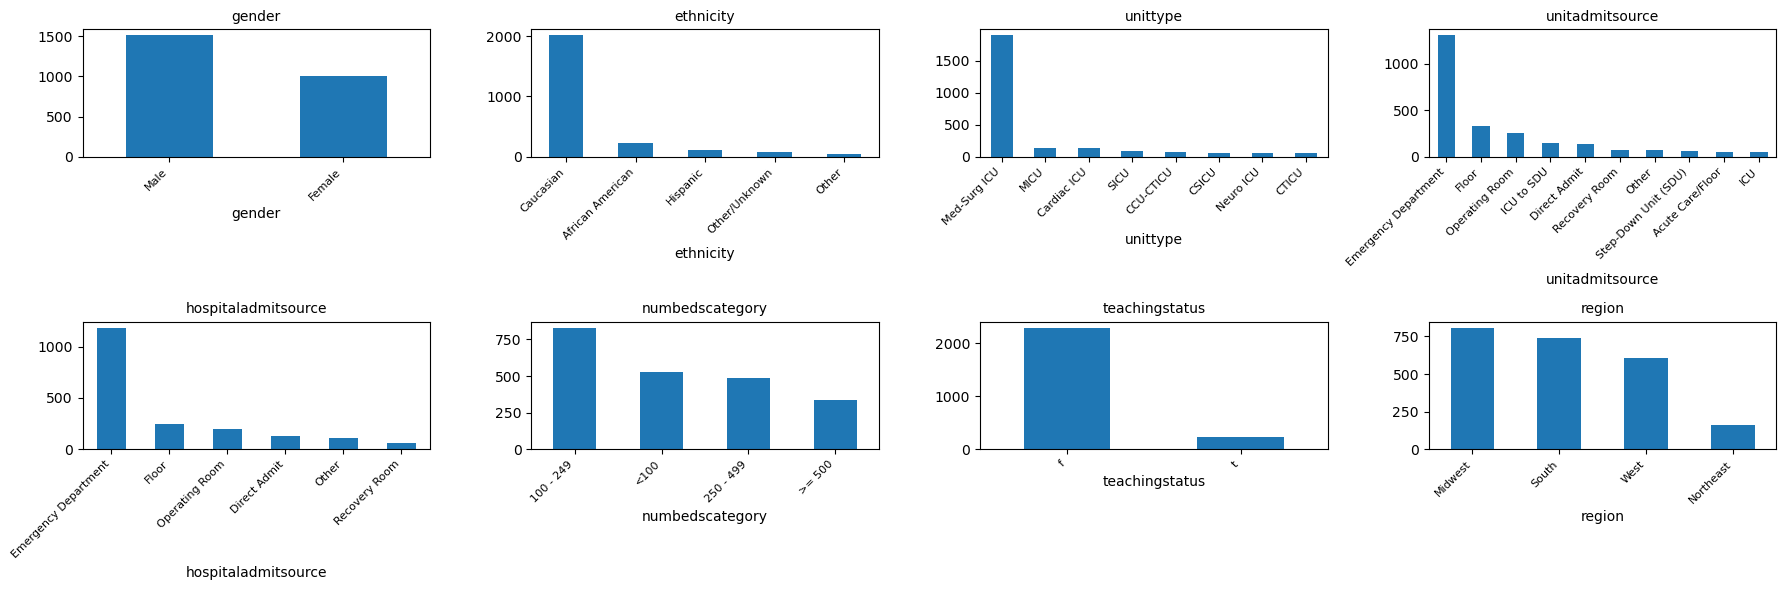

In [53]:
cat_cols_clean = [c for c in prep_df.select_dtypes(include=["category"]).columns]

n = len(cat_cols_clean)
ncols = 4
nrows = int(np.ceil(n / ncols))

plt.figure(figsize=(18, nrows * 3))

for i, col in enumerate(cat_cols_clean, 1):
    plt.subplot(nrows, ncols, i)
    prep_df[col].value_counts().plot(kind='bar')
    plt.title(col, fontsize=10)
    plt.xticks(rotation=45, fontsize=8, ha='right')

plt.tight_layout()
plt.show()

In [55]:
print("\nData Types:\n", prep_df.dtypes)


Data Types:
 gender                  category
ethnicity               category
hospitalid               float64
unittype                category
admissionheight          float64
                          ...   
heartrate_max_log        float64
heartrate_std_log        float64
respiration_mean_log     float64
respiration_max_log      float64
age_years_log            float64
Length: 127, dtype: object


In [57]:
print("Shape:", prep_df.shape)

Shape: (2520, 127)


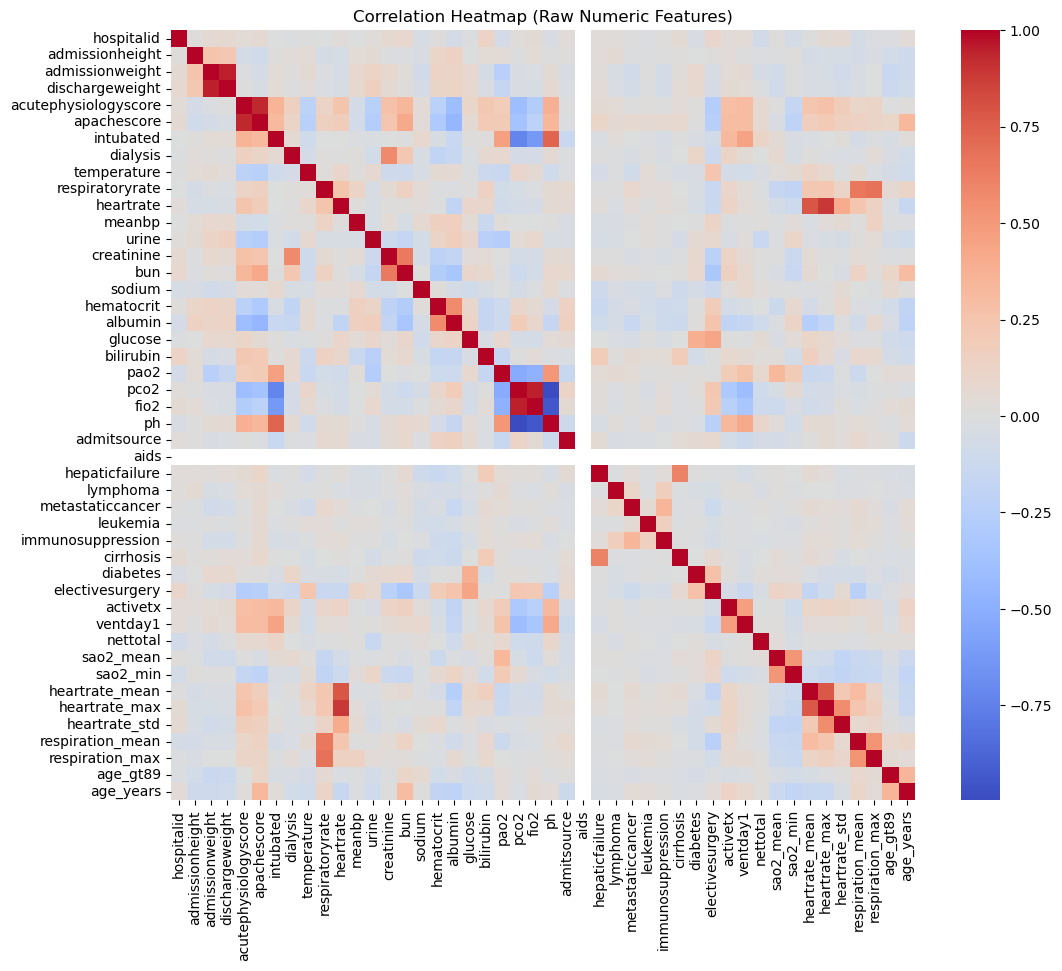

In [59]:
# corr 

plt.figure(figsize=(12, 10))
sns.heatmap(prep_df[num_cols_raw].corr(), cmap='coolwarm', center=0)
plt.title("Correlation Heatmap (Raw Numeric Features)", fontsize=12)
plt.show()

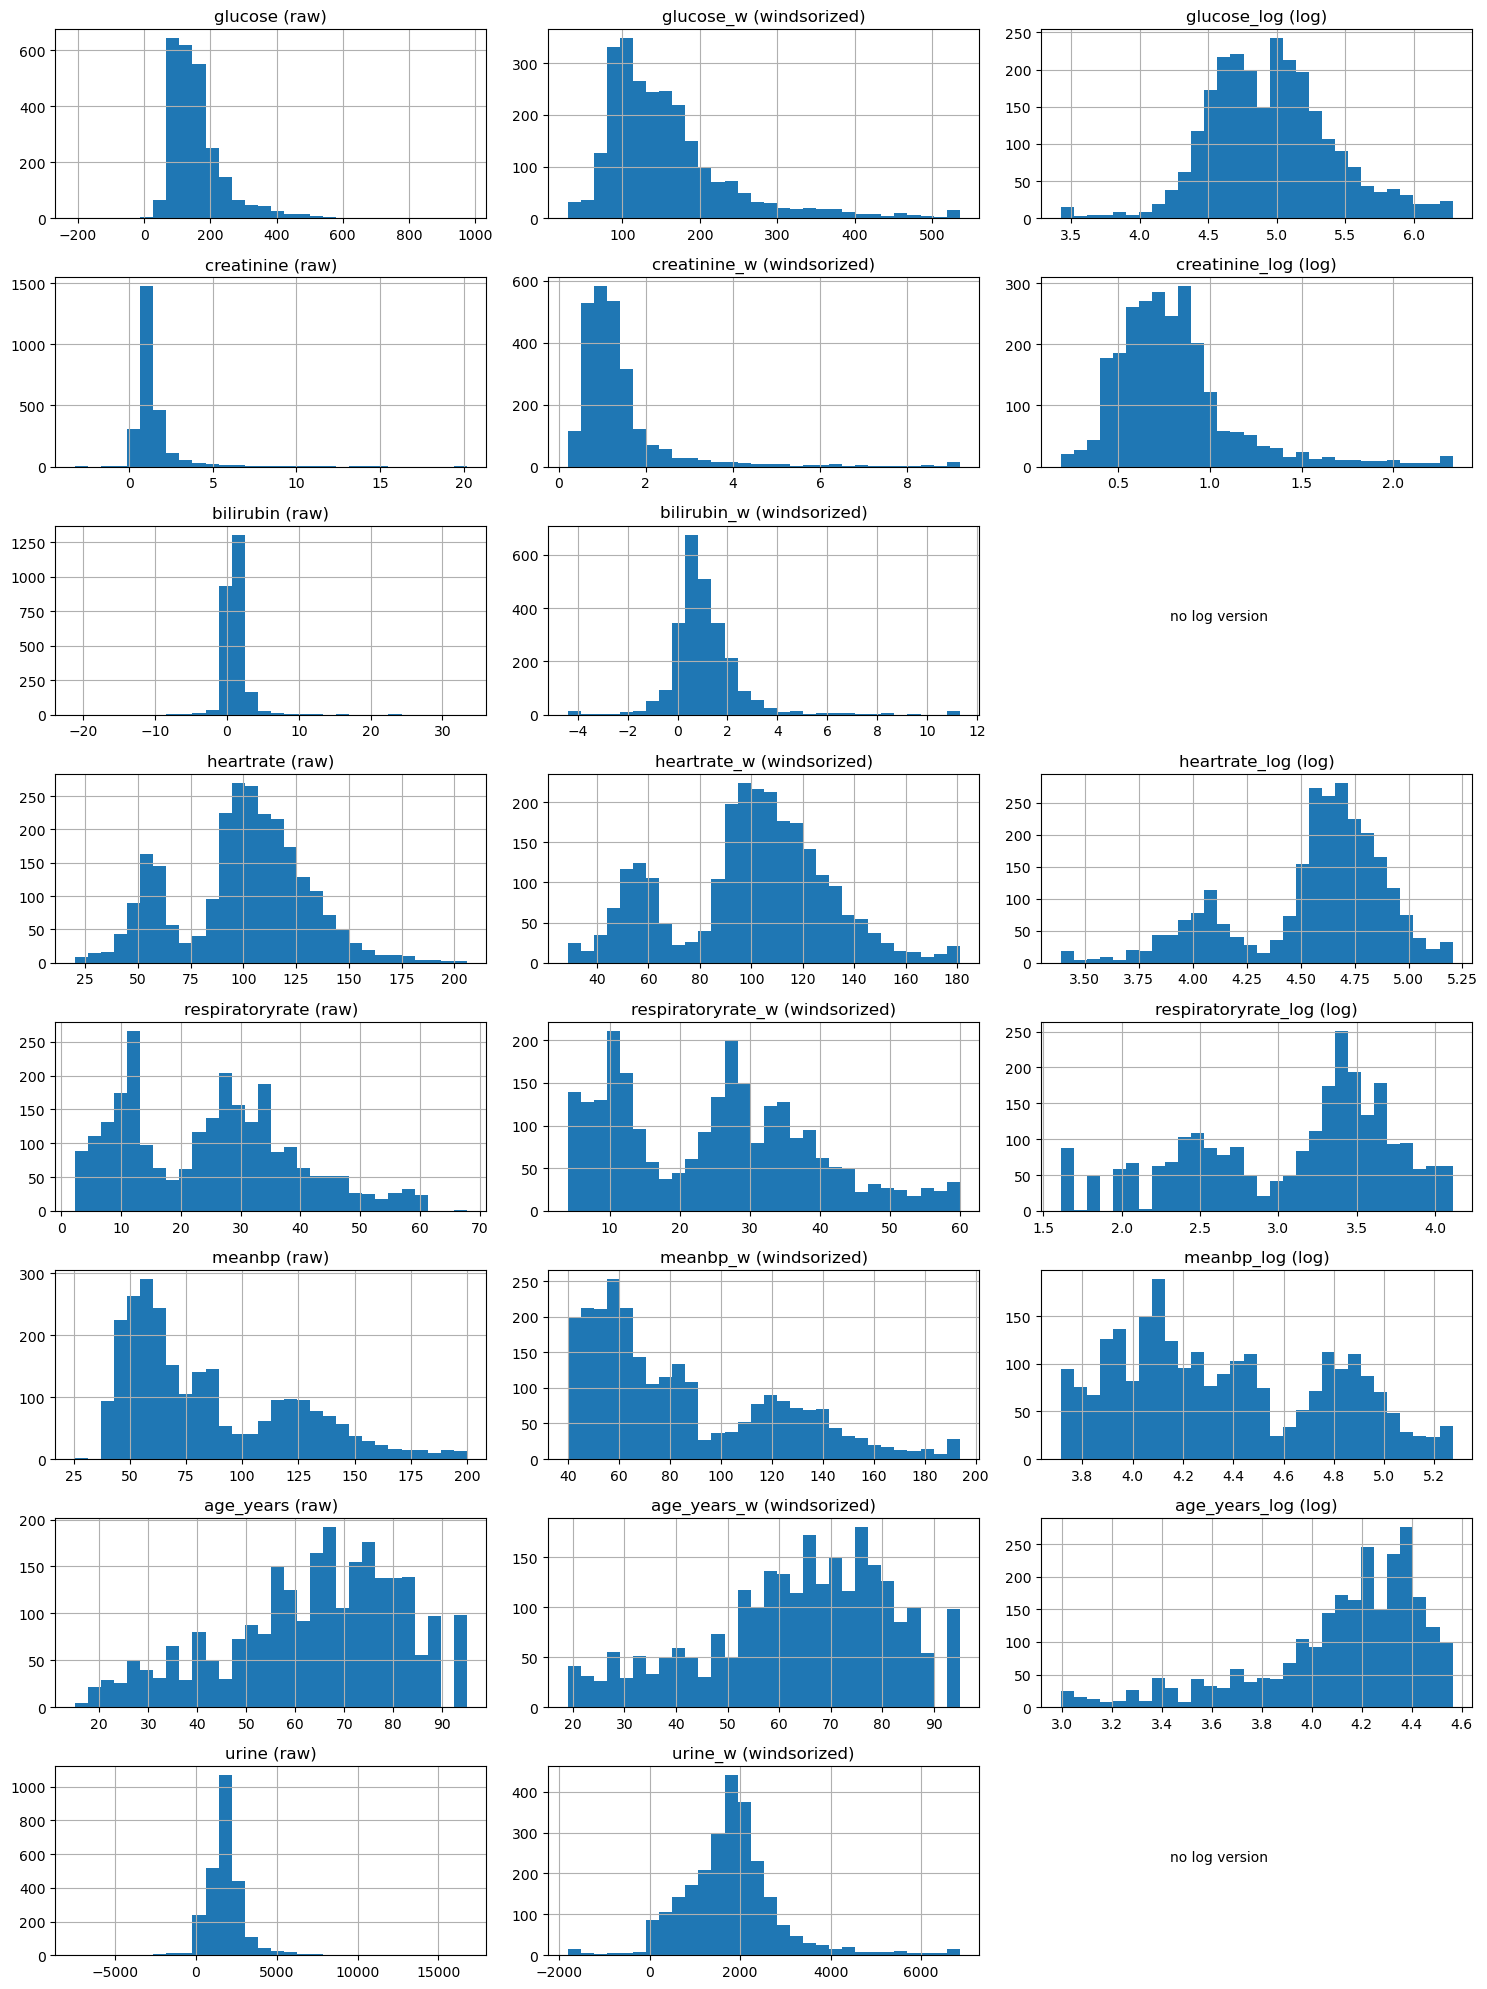

In [61]:
# checking the transformed cols check: 

# key features for inspection
check_features = [
    "glucose", "creatinine", "bilirubin",
    "heartrate", "respiratoryrate", "meanbp",
    "age_years", "urine"
]

n = len(check_features)
plt.figure(figsize=(15, n * 2.5))

for i, col in enumerate(check_features, 1):
    plt.subplot(n, 3, (i-1)*3+1)
    prep_df[col].hist(bins=30)
    plt.title(f"{col} (raw)")
    
    plt.subplot(n, 3, (i-1)*3+2)
    prep_df[f"{col}_w"].hist(bins=30)
    plt.title(f"{col}_w (windsorized)")
    
    if f"{col}_log" in prep_df.columns:
        plt.subplot(n, 3, (i-1)*3+3)
        prep_df[f"{col}_log"].hist(bins=30)
        plt.title(f"{col}_log (log)")
    else:
        plt.subplot(n, 3, (i-1)*3+3)
        plt.text(0.3, 0.5, "no log version", fontsize=10)
        plt.axis("off")

plt.tight_layout()
plt.show()

### filling in nans

In [68]:
# check
print("Final prep_df shape:", prep_df.shape)
print("Any NaNs left?:", prep_df.isna().sum().sum())

Final prep_df shape: (2520, 127)
Any NaNs left?: 1215


In [70]:
na_cols = prep_df.isna().sum()
na_cols[na_cols > 0].sort_values(ascending=False)

hospitaladmitsource    594
numbedscategory        346
region                 210
ethnicity               39
unitadmitsource         22
gender                   4
dtype: int64

In [73]:
# categorical cols we’ve been using
cat_cols = [
    "gender",
    "ethnicity",
    "unittype",
    "unitadmitsource",
    "hospitaladmitsource",
    "numbedscategory",
    "teachingstatus",
    "region"
]

# make sure all are category dtype and add an 'Unknown' level
for c in cat_cols:
    prep_df[c] = prep_df[c].astype("category")
    if "Unknown" not in prep_df[c].cat.categories:
        prep_df[c] = prep_df[c].cat.add_categories("Unknown")
    prep_df[c] = prep_df[c].fillna("Unknown")

# recheck nans
print("Any NaNs left?:", prep_df.isna().sum().sum())

Any NaNs left?: 0


In [76]:
# final check 
print("Final prep_df shape:", prep_df.shape)
print("Any NaNs left?:", prep_df.isna().sum().sum())

Final prep_df shape: (2520, 127)
Any NaNs left?: 0


In [78]:
# save df to csv for modeling
prep_df.to_csv("ICUop_prep.csv", index=False)

--------------------